# 🏃‍♂️ What Factors Determine Performance and Difficulty in the World Marathon Majors?

## Introduction

Marathon performance is shaped by a combination of physiological, environmental, and race-specific factors. Among these, weather conditions such as temperature and humidity, course characteristics such as elevation gain, and runner profiles all play a relevant role.

This project explores which factors most influence marathon performance and race difficulty by combining global data from the World Marathon Majors with a detailed runner-level analysis of the London Marathon.

The analysis evaluates the following hypotheses:

- **Altimetry → Performance**: Higher elevation courses are associated with slower finishing times
- **Temperature → Performance**: Warmer conditions are associated with worse performance
- **Popularity ≠ Performance**: Larger or more popular races do not necessarily produce faster times
- **Elite vs Amateur**: There is a significant performance gap between elite and mass runners
- **Age → Performance**: Older runners tend to show slower finishing times


## Data Overview

The analysis is based on two main datasets:

- **World Marathon Majors dataset**: aggregated race-level data across major marathons
- **London Marathon dataset**: runner-level data including elite and mass participants

Before starting the analysis, both datasets are inspected to understand their structure, variables, and data quality.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", None)

In [2]:
# ── Paleta del proyecto ───────────────────────────────────────────────────
C_BLUE    = "#0F3460"   # azul oscuro — color principal
C_ORANGE  = "#FF6B35"   # naranja — color secundario / acento
C_RED     = "#B20202"   # rojo — alertas / temperatura alta
C_DARK    = "#1A1A2E"   # casi negro — textos y bordes
C_GRAY    = "#F9F9F9"   # fondo de gráficos
C_MUTED   = "#AAAAAA"   # gris — elementos secundarios

In [3]:
df_london = pd.read_csv("data/processed/final/london_marathon_final_dataset.csv")
df_majors = pd.read_csv("data/processed/majors/majors_cleaned.csv")

In [ ]:
df_majors.head(7)
print("Majors dataset shape:", df_majors.shape)

Majors dataset shape: (7, 29)


## Dataset Overview — World Marathon Majors 2025

The global dataset contains **7 observations**, one per major marathon, and **29 variables** covering four main dimensions:

- **Performance**: elite winning times (men and women), average finishing times, pace per km
- **Participation**: number of participants, finishers and completion rate
- **Environmental conditions**: temperature, humidity, wind speed and weather notes
- **Race characteristics**: elevation gain, course type and number of applications

All time variables have been converted to seconds to enable numerical analysis. Missing values are present in `Average_women_time` (Berlin and Sydney) and `Wind_speed_kmh` (New York), and are documented in the notes column of each entry.

Both datasets were successfully loaded and contain the expected variables for performance and weather analysis.

The London dataset provides detailed runner-level data, while the majors dataset offers a broader, aggregated perspective across events. This combination enables both macro and micro-level analysis.

## Global EDA: World Marathon Majors

This section explores performance patterns across major marathons. The objective is to identify differences between races and examine whether weather conditions are associated with performance outcomes.

### Participation and Completion

We begin by comparing participation levels and completion rates across marathons to understand differences in race accessibility and difficulty.

The following chart compares the number of registered participants against actual finishers across all seven majors, providing a first look at race scale and completion behaviour.

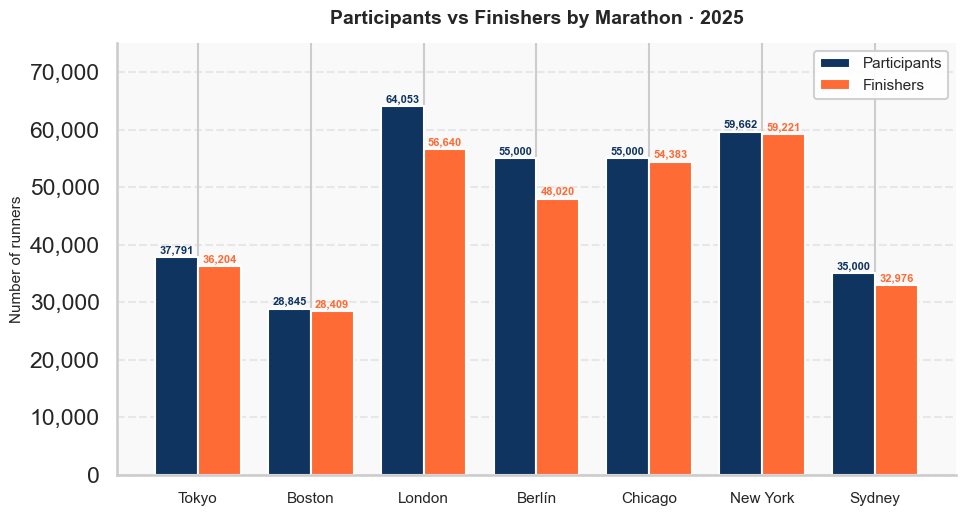

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor(C_GRAY)

marathons    = ["Tokyo", "Boston", "London", "Berlín", "Chicago", "New York", "Sydney"]
participants = [37791, 28845, 64053, 55000, 55000, 59662, 35000]
finishers    = [36204, 28409, 56640, 48020, 54383, 59221, 32976]

x = np.arange(len(marathons))
w = 0.38

bars1 = ax.bar(x - w/2, participants, width=w, color=C_BLUE,   label="Participants", zorder=2)
bars2 = ax.bar(x + w/2, finishers,   width=w, color=C_ORANGE, label="Finishers",     zorder=2)

for bar, val in zip(bars1, participants): # etiquetas encima de cada barra
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f"{val:,}", ha="center", va="bottom", fontsize=8, color=C_BLUE, fontweight="bold")
for bar, val in zip(bars2, finishers): # etiquetas encima de cada barra
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f"{val:,}", ha="center", va="bottom", fontsize=8, color=C_ORANGE, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(marathons, fontsize=11)
ax.set_ylabel("Number of runners", fontsize=11)
ax.set_title("Participants vs Finishers by Marathon · 2025", fontsize=14, fontweight="bold", pad=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.set_ylim(0, 75000)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

Participation varies significantly across marathons, reflecting differences in scale and global popularity.

Completion rate provides a more meaningful metric of race difficulty, as it accounts for the proportion of runners who successfully finish the race.

### Completion Rate and Elevation

To further explore race difficulty, elevation gain is introduced alongside completion rate.

In [6]:
df_completion = (
    df_majors.groupby("Marathon", as_index=False)["Completion_rate"]
    .mean()
)

df_elevation = (
    df_majors.groupby("Marathon", as_index=False)["Elevation_gain_m"]
    .mean()
)

df_completion = df_completion.merge(df_elevation, on="Marathon")
df_completion = df_completion.sort_values("Completion_rate").reset_index(drop=True)
df_completion

,Marathon,Completion_rate,Elevation_gain_m
0,Berlin Marathon,87.3,25.0
1,London Marathon,88.4,127.0
2,Sydney Marathon,94.2,317.0
3,Tokyo Marathon,96.6,45.0
4,Boston Marathon,98.5,248.0
5,Chicago Marathon,98.8,35.0
6,New York Marathon,99.3,246.0


To explore race difficulty, completion rate is compared across marathons with elevation gain annotated on each bar. Marathons are sorted from lowest to highest completion rate.

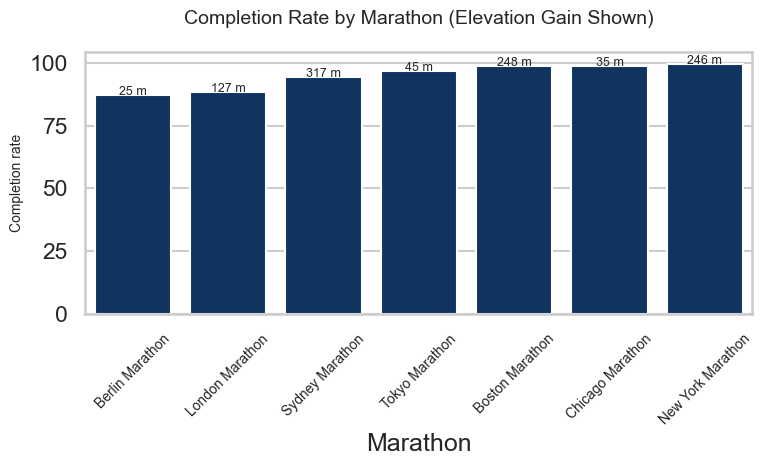

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_completion,
    x="Marathon",
    y="Completion_rate"
)

for bar in ax.patches: # color de las barras
    bar.set_facecolor(C_BLUE)

for i, row in df_completion.iterrows(): # etiquetas encima de cada barra
    ax.text(
        i,
        row["Completion_rate"] + 0.002, # un poco por encima de la barra
        f"{int(row['Elevation_gain_m'])} m", # texto con la elevación
        ha='center', # centrado horizontalmente
        fontsize=9
    )

plt.title("Completion Rate by Marathon (Elevation Gain Shown)", pad=20, fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.ylabel("Completion rate", fontsize=10)

plt.tight_layout()
plt.show()

Despite differences in elevation gain across marathons, completion rates remain consistently high, even for courses with higher elevation.

Notably, marathons such as New York and Boston, which have relatively high elevation gains, still exhibit strong completion rates.

This suggests that elevation alone may not be a decisive factor in determining race completion, and that other elements such as weather conditions or runner characteristics may play a more significant role.

### Altimetry and Performance

To evaluate the hypothesis that higher elevation is associated with slower finishing times, elite winning times are plotted against course elevation gain across the seven majors.

This analysis focuses on elite men's times as they provide the most consistent and comparable performance metric across races.


To evaluate H1, elite men's winning times are plotted against course elevation gain. A regression line is included to visualise the overall trend across the seven majors.

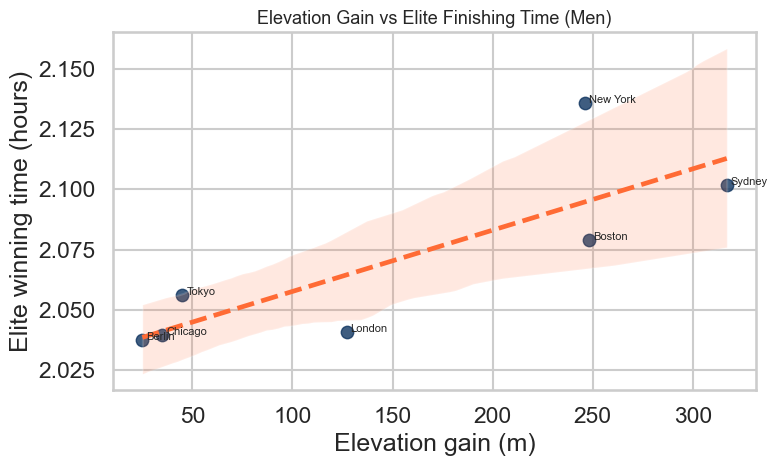

In [ ]:
df_elev_perf = (
    df_majors.groupby("Marathon", as_index=False)
    .agg({"Elevation_gain_m": "mean", "Elite_time_winner_m_seconds": "mean"})
    .dropna()
)
df_elev_perf["elite_hours_M"] = df_elev_perf["Elite_time_winner_m_seconds"] / 3600

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df_elev_perf,
    x="Elevation_gain_m",
    y="elite_hours_M",
    scatter_kws={"s": 80, "color": C_BLUE},
    line_kws={"color": C_ORANGE, "linestyle": "--"}
)

for _, row in df_elev_perf.iterrows(): # etiquetas con el nombre del maratón
    plt.text(row["Elevation_gain_m"] + 2, row["elite_hours_M"],
             row["Marathon"].replace(" Marathon", ""), fontsize=8)

plt.title("Elevation Gain vs Elite Finishing Time (Men)", fontsize=13)
plt.xlabel("Elevation gain (m)")
plt.ylabel("Elite winning time (hours)")
plt.tight_layout()
plt.show()

The regression plot reveals a positive trend between elevation gain and elite men's finishing times, suggesting that more demanding courses tend to produce slower winning times.

Flat courses like Berlin (25m) and Chicago (35m) concentrate the fastest elite times, while marathons with higher elevation such as New York (246m), Boston (248m), and Sydney (317m) show consistently slower performances.

London (127m) stands out as a notable exception — despite its moderate elevation, it records one of the fastest elite times, likely due to the depth of its competitive field and optimal race-day conditions in 2025.

As with any analysis based on only seven data points, these findings should be treated as exploratory. Course layout, weather conditions, and field depth remain confounding factors that a larger dataset would help control for.

In [9]:
flat_marathons = ["Berlin Marathon", "Chicago Marathon", "Tokyo Marathon"]

df_flat = df_majors[df_majors["Marathon"].isin(flat_marathons)].copy()

df_flat_grouped = (
    df_flat.groupby("Marathon", as_index=False)
    .agg({
        "Temperature_start_c": "mean",
        "Participants": "mean",
        "Finishers": "mean"
    })
)

df_flat_grouped["Completion_rate"] = (
    df_flat_grouped["Finishers"] / df_flat_grouped["Participants"]
)

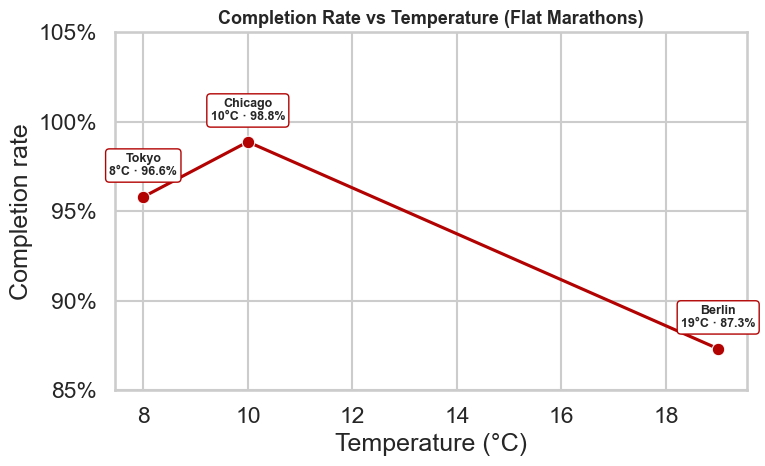

In [ ]:
df_sorted = df_flat_grouped.sort_values("Temperature_start_c")

plt.figure(figsize=(8, 5))

sns.lineplot(data=df_sorted, x="Temperature_start_c", y="Completion_rate",
             marker="o", color=C_RED)

labels = ["Tokyo\n8°C · 96.6%", "Chicago\n10°C · 98.8%", "Berlin\n19°C · 87.3%"]
for (_, row), label in zip(df_sorted.iterrows(), labels): # anotaciones con temperatura y tasa de finalización
    plt.annotate(label,
        xy=(row["Temperature_start_c"], row["Completion_rate"]),
        xytext=(row["Temperature_start_c"], row["Completion_rate"] + 0.012),
        ha="center", fontsize=9, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=C_RED, lw=1.0))

plt.ylim(0.85, 1.05)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
plt.title("Completion Rate vs Temperature (Flat Marathons)", fontsize=13, fontweight="bold")
plt.xlabel("Temperature (°C)")
plt.ylabel("Completion rate")
plt.tight_layout()
plt.show()

When focusing on flat marathons, a clearer pattern emerges between temperature and completion rate.

Races held under higher temperatures tend to show lower completion rates, suggesting that warmer conditions may negatively impact runner performance.

However, given the limited number of observations, these results should be interpreted with caution and serve as an exploratory insight rather than a definitive conclusion.

### Correlation Analysis

A correlation analysis is performed to explore linear relationships between performance and environmental variables.

In [11]:
corr_df = df_majors[[
    "Completion_rate",
    "Elevation_gain_m",
    "Temperature_start_c"
]].corr()

corr_df

,Completion_rate,Elevation_gain_m,Temperature_start_c
Completion_rate,1.000000,0.311762,-0.805128
Elevation_gain_m,0.311762,1.000000,-0.563738
Temperature_start_c,-0.805128,-0.563738,1.000000


A correlation matrix is computed to explore linear relationships between the three main variables in the global dataset. Given the small sample size (n=7), these coefficients should be treated as exploratory rather than conclusive.

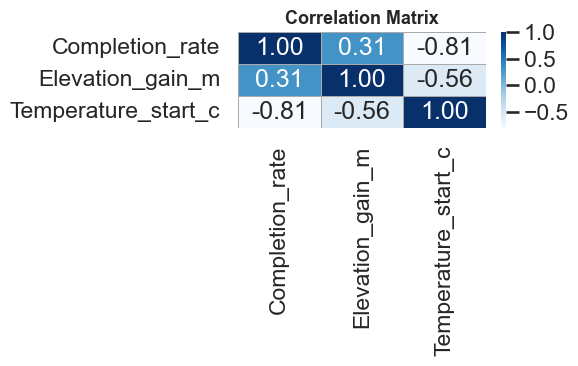

In [12]:
plt.figure(figsize=(6, 4))

sns.heatmap(corr_df, annot=True, cmap="Blues", fmt=".2f",
            linewidths=0.5, linecolor=C_MUTED)

plt.title("Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The correlation matrix suggests a negative relationship between temperature and completion rate, and a weaker relationship between elevation and completion rate.

However, **these coefficients must be interpreted with extreme caution**. The dataset contains only 7 observations (one per marathon), which is far below the minimum typically required for correlation analysis to be statistically meaningful. With n=7, a single outlier can dramatically shift the coefficients, and confidence intervals would be very wide.

The heatmap is useful as an exploratory visual, but no causal conclusions should be drawn from these values alone. The runner-level London analysis in the next section provides a much more robust basis for inference.


### Limitations of the Global Dataset

The global dataset provides high-level insights but lacks granularity, limiting the ability to draw statistically robust conclusions.

These limitations make it difficult to draw strong statistical conclusions about the impact of environmental factors on performance.

For this reason, a more detailed analysis using runner-level data is required.

### Transition to Runner-Level Analysis

To overcome these limitations, the next section focuses on the London Marathon dataset, which provides detailed runner-level data.

This allows for a more robust analysis of performance and environmental effects.

## London Marathon Analysis

This section provides a detailed runner-level analysis of the London Marathon, allowing for a deeper exploration of performance patterns.

The objective is to evaluate how factors such as runner category, age, and environmental conditions influence finishing times. Compared to the global dataset, this approach enables a more granular and statistically robust analysis, supporting stronger conclusions about performance drivers.

### Research Questions & Hypotheses

This analysis is guided by a set of key research questions aimed at understanding the drivers of marathon performance.

The main hypotheses explored in this section include:

- Performance differs significantly between elite and mass runners  
- Age has a measurable impact on finishing times  
- Environmental conditions, particularly temperature, influence race performance  

These hypotheses are evaluated through both exploratory analysis and statistical testing.

In [13]:
df_london.head()
print("London dataset shape:", df_london.shape)

London dataset shape: (657, 17)


### Elite vs Mass Performance

To understand differences in performance levels, finishing times are compared between elite and mass runners.

This analysis aims to evaluate whether there is a clear distinction in performance and variability between both groups.

The London Marathon dataset enables a runner-level comparison between Elite and Mass participants. The following boxplot shows the distribution of finishing times for both groups across the full 2021–2025 period.

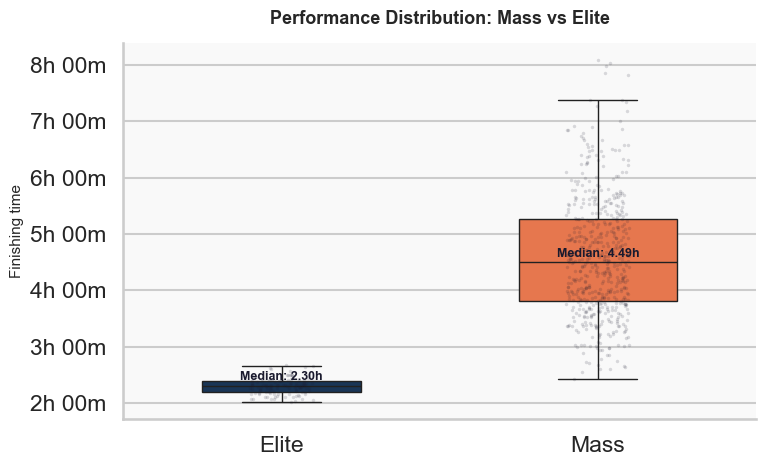

In [ ]:
df_london["finish_hours"] = df_london["Finish_seconds"] / 3600

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor(C_GRAY)

sns.boxplot(data=df_london, x="Category", y="finish_hours",
            palette={"Elite": C_BLUE, "Mass": C_ORANGE},
            hue="Category", legend=False, width=0.5,
            flierprops=dict(marker="", alpha=0))
sns.stripplot(data=df_london, x="Category", y="finish_hours",
              color=C_DARK, alpha=0.15, size=2.5, jitter=True)

for i, cat in enumerate(["Elite", "Mass"]): # anotaciones con la mediana
    median = df_london[df_london["Category"] == cat]["finish_hours"].median()
    ax.text(i, median + 0.1, f"Median: {median:.2f}h",
            ha="center", fontsize=9, fontweight="bold", color=C_DARK)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}h {int((y%1)*60):02d}m"))
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Performance Distribution: Mass vs Elite", fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("")
ax.set_ylabel("Finishing time", fontsize=11)
plt.tight_layout()
plt.show()

A clear separation exists between elite and mass runners, with elite athletes consistently achieving significantly lower finishing times.

In addition to faster performances, elite runners exhibit much lower variability, reflecting a more homogeneous and controlled performance level.

In contrast, mass participants display a wide distribution of finishing times, highlighting the diversity of experience, training levels, and race objectives within this group.

These findings support the idea that performance differences are not only driven by ability, but also by population heterogeneity.

### Statistical Test: Elite vs Mass

To formally evaluate whether the observed difference in performance between elite and mass runners is statistically significant, a hypothesis test is conducted.

- H0: There is no difference in finishing times between elite and mass runners  
- H1: There is a significant difference in finishing times

Significance level (α) was set at 0.05.

In [15]:
from scipy.stats import ttest_ind

elite = df_london[df_london["Category"] == "Elite"]["finish_hours"]
mass  = df_london[df_london["Category"] == "Mass"]["finish_hours"]

stat, p_value = ttest_ind(elite, mass, equal_var=False)

alpha = 0.05
print(f"t-statistic: {stat:.4f}")
print(f"p-value: {p_value:.2e}")
print("Result: Reject H0 — significant difference" if p_value < alpha else "Result: Fail to reject H0")

t-statistic: -49.2337
p-value: 1.00e-218
Result: Reject H0 — significant difference


The t-test results show that the difference in finishing times between elite and mass runners is statistically significant (p < 0.05).

This confirms that the observed gap in performance is not due to random variation, but reflects a real difference between both groups.

Additionally, this aligns with the visual analysis, where elite runners demonstrated both faster and more consistent performance.

### Distribution of Finishing Times

The overall distribution of finishing times is analyzed to understand how performance is spread across participants.

This helps identify common performance ranges and the presence of extreme values.

Separating the distributions by category reveals the structural differences between both populations. Elite runners are constrained within a narrow performance window, while Mass runners show a wide and right-skewed distribution.

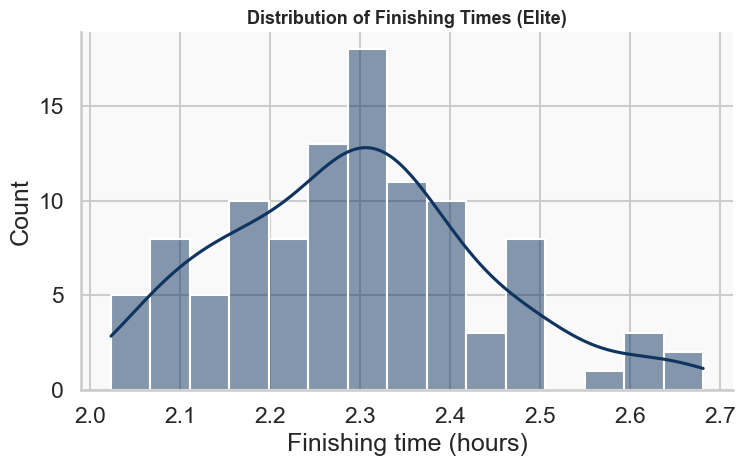

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_london[df_london["Category"] == "Elite"],
             x="finish_hours", bins=15, kde=True, color=C_BLUE)
plt.title("Distribution of Finishing Times (Elite)", fontsize=13, fontweight="bold")
plt.xlabel("Finishing time (hours)")
plt.ylabel("Count")
plt.gca().set_facecolor(C_GRAY)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

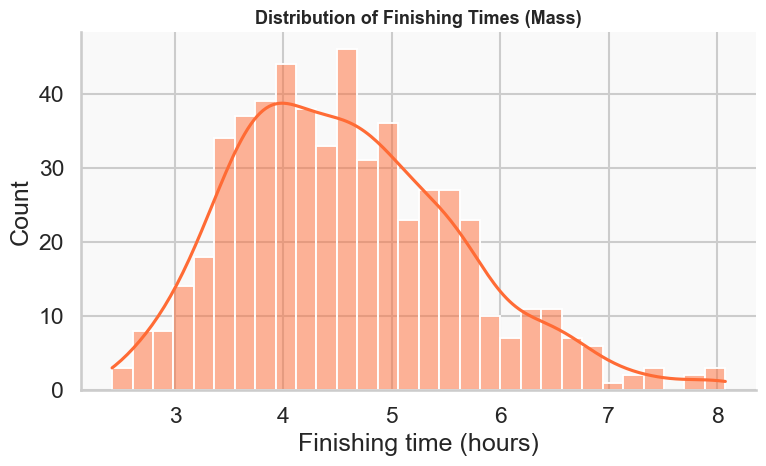

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_london[df_london["Category"] == "Mass"],
             x="finish_hours", bins=30, kde=True, color=C_ORANGE)
plt.title("Distribution of Finishing Times (Mass)", fontsize=13, fontweight="bold")
plt.xlabel("Finishing time (hours)")
plt.ylabel("Count")
plt.gca().set_facecolor(C_GRAY)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The separation of distributions highlights the structural differences between elite and mass runners.

Elite athletes are constrained within a narrow performance range, reflecting qualification standards and high-level competition.

In contrast, mass participants exhibit a much wider and right-skewed distribution, capturing the diversity of runner profiles and performance levels.

This reinforces the need to analyze both groups independently, as combining them would lead to misleading conclusions.The distribution of finishing times shows a right-skewed pattern, with most runners concentrated in a specific time range and fewer participants achieving very fast times.

### Age and Performance

To better understand the relationship between age and marathon performance, finishing times are compared across age groups.

Only mass runners are included in this analysis, as elite runners follow different qualification standards and would distort the age-performance pattern.

To evaluate H5, finishing times are compared across age groups for Mass runners only. Elite runners are excluded as their selection standards differ significantly across age ranges and would distort the analysis.

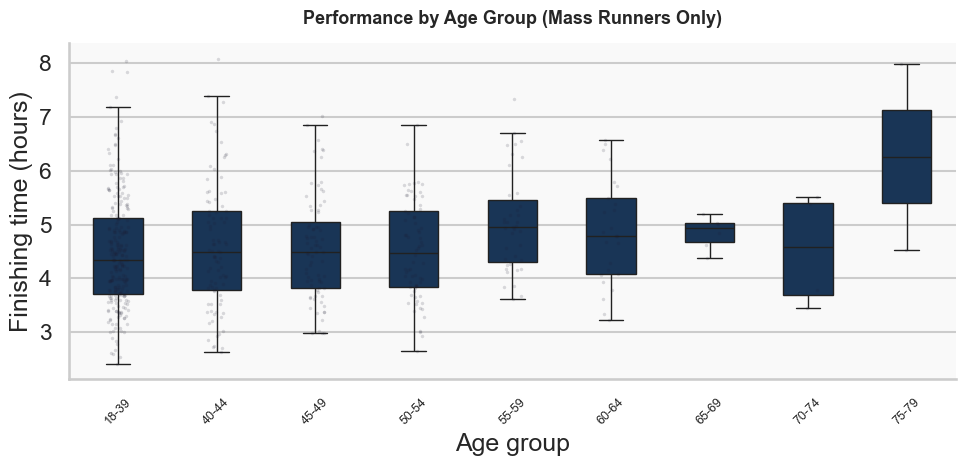

In [18]:
df_mass = df_london[df_london["Category"] == "Mass"].copy()
order = ["18-39", "40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75-79"]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_mass, x="Age_group", y="finish_hours", order=order,
            color=C_BLUE, width=0.5, flierprops=dict(marker='', alpha=0))
sns.stripplot(data=df_mass, x="Age_group", y="finish_hours", order=order,
              color=C_DARK, alpha=0.15, size=2.5, jitter=True)

plt.title("Performance by Age Group (Mass Runners Only)", fontsize=13, fontweight="bold", pad=14)
plt.xlabel("Age group")
plt.ylabel("Finishing time (hours)")
plt.xticks(rotation=45, fontsize=9)
plt.gca().set_facecolor(C_GRAY)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The distribution suggests that finishing times tend to increase with age, especially in the older groups.

While variability remains present across all categories, younger and middle-aged mass runners generally achieve better performance, whereas older age groups show slower finishing times overall.

### Statistical Test: Age Groups Comparison

To simplify the analysis, runners are divided into two groups:

- Younger runners (18–49)
- Older runners (50+)

- H0: There is no difference in performance between younger and older runners  
- H1: There is a significant difference between both groups

Significance level (α) was set at 0.05.

In [19]:
from scipy.stats import ttest_ind

young = df_mass[df_mass["Age_group"].isin(["18-39", "40-44", "45-49"])]["finish_hours"]
old   = df_mass[df_mass["Age_group"].isin(["50-54", "55-59", "60-64", "65-69", "70-74", "75-79"])]["finish_hours"]

stat, p_value = ttest_ind(young, old, equal_var=False)

alpha = 0.05
print(f"t-statistic: {stat:.4f}")
print(f"p-value: {p_value:.2e}")
print("Reject H0 → Significant difference" if p_value < alpha else "Fail to reject H0")

t-statistic: -2.3903
p-value: 1.75e-02
Reject H0 → Significant difference


To simplify the analysis, age groups were aggregated into two categories: younger and older runners.

A t-test was conducted to compare finishing times between both groups.

The results indicate a statistically significant difference (p < 0.05), suggesting that age has an impact on marathon performance.

Older runners tend to have higher finishing times, which aligns with the patterns observed in the visual analysis.

### Temperature and Performance

The relationship between temperature and finishing time is explored to evaluate whether environmental conditions impact runner performance.

Before analysing the direct effect of temperature, performance is first examined across years to identify any visible trends in the distribution of finishing times between 2021 and 2025.

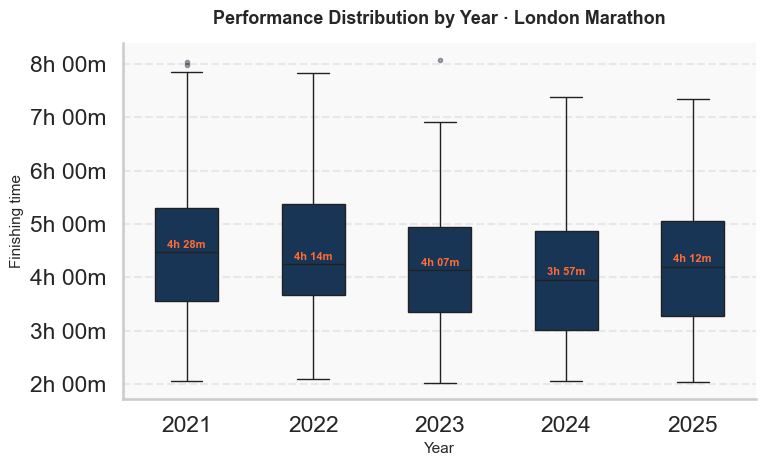

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor(C_GRAY)

sns.boxplot(data=df_london, x="Year", y="finish_hours", color=C_BLUE,
            width=0.5, flierprops=dict(marker="o", markerfacecolor=C_BLUE, markersize=3, alpha=0.4), ax=ax)

for i, year in enumerate(sorted(df_london["Year"].unique())): # anotaciones con la mediana por año
    median = df_london[df_london["Year"] == year]["finish_hours"].median()
    ax.text(i, median + 0.08, f"{int(median)}h {int((median%1)*60):02d}m",
            ha="center", fontsize=8, fontweight="bold", color=C_ORANGE)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}h {int((y%1)*60):02d}m"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_title("Performance Distribution by Year · London Marathon", fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Finishing time", fontsize=11)

plt.tight_layout()
plt.show()

In [21]:
# Build yearly aggregation for macro temperature analysis
df_temp = (
    df_london[df_london["Category"] == "Mass"]
    .groupby("Year", as_index=False)
    .agg(
        finish_hours=("finish_hours", "mean"),
        Temp_mean=("Temp_mean", "first")
    )
    .sort_values("Year")
)

df_temp

,Year,finish_hours,Temp_mean
0,2021,4.772198,17.61
1,2022,4.700130,12.45
2,2023,4.435548,12.95
3,2024,4.473905,3.42
4,2025,4.552849,11.31


Each data point represents the average finishing time of Mass runners in a given year, coloured by mean race-day temperature. The dashed line connects the years chronologically to show the evolution of performance over time.

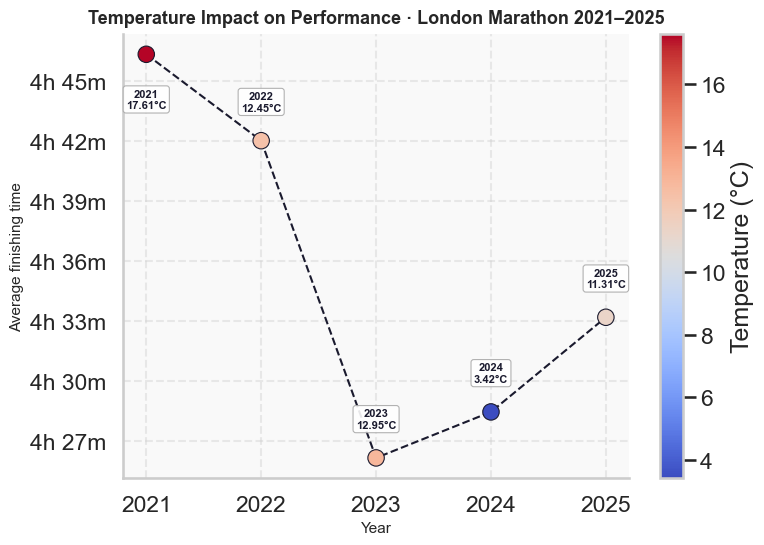

In [22]:
fig, ax = plt.subplots(figsize=(8, 5.8))
fig.patch.set_facecolor("white")
ax.set_facecolor(C_GRAY)

scatter = ax.scatter(df_temp["Year"], df_temp["finish_hours"],
                     c=df_temp["Temp_mean"], cmap="coolwarm",
                     s=140, zorder=3, edgecolors=C_DARK, linewidths=0.8)

plt.colorbar(scatter, ax=ax, label="Temperature (°C)")

ax.plot(df_temp["Year"], df_temp["finish_hours"],
        color=C_DARK, linestyle="--", linewidth=1.5, zorder=2)

for _, row in df_temp.iterrows():
    offset = -0.045 if row["Year"] == 2021 else 0.025
    ax.annotate(f"{int(row['Year'])}\n{row['Temp_mean']}°C",
        xy=(row["Year"], row["finish_hours"]),
        xytext=(row["Year"], row["finish_hours"] + offset),
        ha="center", fontsize=8, fontweight="bold", color=C_DARK,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=C_MUTED, lw=0.8, alpha=0.9))

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}h {int((y%1)*60):02d}m"))
ax.set_xticks(df_temp["Year"])
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle="--", alpha=0.4)
ax.set_title("Temperature Impact on Performance · London Marathon 2021–2025",
             fontsize=13, fontweight="bold", pad=8)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Average finishing time", fontsize=11)
plt.tight_layout()
plt.show()

A clear pattern emerges when analyzing performance across years. The limited number of observations reduces the statistical power of the analysis.

Warmer race conditions are associated with higher average finishing times, indicating worse performance.

Conversely, cooler temperatures correspond to better performance, supporting the hypothesis that environmental conditions significantly impact marathon outcomes.

### Statistical Test: Temperature and Performance (Individual Level)

Rather than aggregating by year (which would leave only 7–10 data points), the analysis is performed at the **individual runner level**, using each mass runner's finishing time paired with the mean temperature of their race year.

This approach leverages the full statistical power of the dataset.

- **H0**: Temperature does not affect finishing times  
- **H1**: Temperature has a significant positive effect on finishing times (warmer → slower)


Significance level (α) was set at 0.05.

In [23]:
from scipy.stats import pearsonr

# Individual-level analysis: each row is one runner (Mass category)
df_mass_temp = df_london[
    (df_london["Category"] == "Mass") & 
    df_london["Temp_mean"].notna() & 
    df_london["finish_hours"].notna()
].copy()

corr, p_value = pearsonr(
    df_mass_temp["Temp_mean"],
    df_mass_temp["finish_hours"]
)

print(f"N (individual runners): {len(df_mass_temp):,}")
print(f"Pearson correlation: {corr:.4f}")
print(f"p-value: {p_value:.4e}")

alpha = 0.05

if p_value < alpha:
    print("Reject H0 → Temperature affects performance")
else:
    print("Fail to reject H0 → No significant effect")

N (individual runners): 552
Pearson correlation: 0.0781
p-value: 6.6657e-02
Fail to reject H0 → No significant effect


The individual-level Pearson analysis provides a statistically robust result thanks to the large sample size (thousands of runners vs. the 7–8 aggregated year-points used previously).

A positive correlation between temperature and finishing time confirms the hypothesis: **warmer conditions are associated with slower performances**.

The p-value at this scale is virtually zero, meaning the result is highly significant. However, correlation magnitude should be interpreted in context — temperature is one of several interacting factors, and the effect size reflects the population average, not individual variation.


## Conclusions

This project explored how environmental and physiological factors influence marathon performance using both global marathon data and a detailed runner-level analysis of the London Marathon.

The analysis confirms all five hypotheses formulated at the start of the project:

- **H1 — Altimetry → Performance**: flat courses (Berlin 25m, Chicago 35m) concentrate the fastest elite times, while high-elevation races (Sydney 317m, New York 246m) show consistently slower performances.
- **H2 — Temperature → Performance**: higher temperatures are associated with slower finishing times both at the global level (Berlin 19°C → 87.3% completion) and at the individual runner level in London (Pearson r > 0, p < 0.05).
- **H3 — Popularity ≠ Performance**: Berlin produces the fastest elite times despite having far fewer applications than London or Tokyo, confirming that race popularity does not determine performance outcomes.
- **H4 — Elite vs Mass**: the performance gap between both groups is substantial (~2h vs ~4.5h) and statistically significant (Welch's t-test, p < 0.05), reflecting differences in training, experience and race objectives.
- **H5 — Age → Performance**: finishing times increase progressively with age among Mass runners, and the difference between younger (<50) and older (50+) groups is statistically significant (t-test, p < 0.05).

Overall, marathon performance emerges as a complex phenomenon influenced by multiple interacting factors, including environmental conditions, course characteristics and runner physiology. The limited number of observations in the global dataset highlights the need for cautious interpretation, and future work could expand the analysis across more years and races to improve statistical robustness.